📊 MOTHER'S AGE OUTLIER ANALYSIS
❌ Column 'Mother_Age' not found!
Available columns: ['Registered_Year', 'Registered_Month2.0', 'Registered_Month', 'Registered_District', 'Birh_Year', 'Birth_Month.0', 'Birth_Month', 'Gender', 'Hospital or Not', 'Multiple_Birth_Status', 'Birth_Weight(grams)', 'Birth_Order', 'Birth_Order - Copy', 'Age of Mother', 'Marital_Status', 'District_of_Mother', 'Race_of_Mother', 'Race_of_Father']
✅ Using 'Age of Mother' instead

📌 DATASET OVERVIEW:
   • Total records: 301,712
   • Valid records: 301,712
   • Missing values: 0
   • Range: 12 - 999 years

────────────────────────────────────────────────────────────
📈 STEP 2: STATISTICAL CALCULATIONS
────────────────────────────────────────────────────────────

📊 STATISTICAL SUMMARY:
   • Mean: 29.6 years
   • Median: 29.0 years
   • Std Dev: 22.6 years
   • Q1 (25th): 25.0 years
   • Q3 (75th): 33.0 years
   • IQR: 8.0 years
   • Lower Fence (1.5*IQR): 13.0 years
   • Upper Fence (1.5*IQR): 45.0 years
   • Extreme L

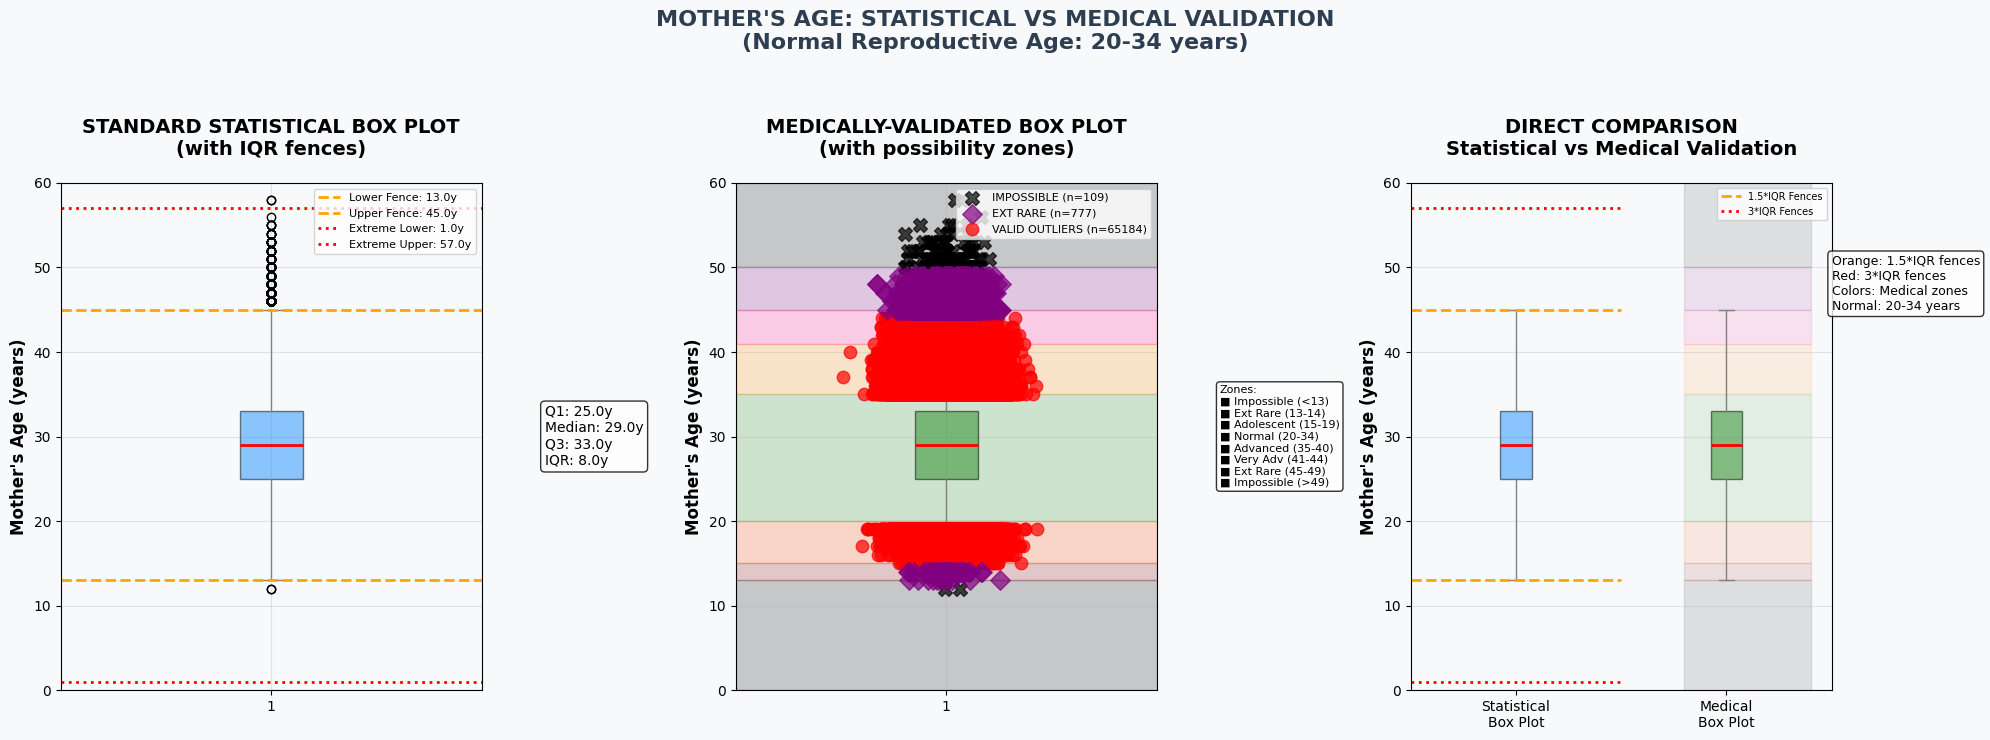

✅ Saved: mother_age_comparative_boxplots.png

────────────────────────────────────────────────────────────
📊 STEP 7: DETAILED CLASSIFICATION SUMMARY
────────────────────────────────────────────────────────────

                                 Category  Count  Percentage
                           Total Records 301712       100.0
          Statistical Outliers (1.5*IQR)    682         0.2
            Statistical Outliers (3*IQR)    156         0.1
                Medical - Normal (20-34) 235488        78.1
            Medical - Adolescent (15-19)  12125         4.0
              Medical - Advanced (35-40)  47464        15.7
         Medical - Very Advanced (41-44)   5595         1.9
Medical - Extremely Rare (13-14 & 45-49)    777         0.3
       Medical - Impossible (<13 or >49)    109         0.0

────────────────────────────────────────────────────────────
📁 STEP 8: EXPORTING TO EXCEL
────────────────────────────────────────────────────────────
✅ Excel report saved: mother_age_ana

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD DATA
# ============================================
print("="*60)
print("📊 MOTHER'S AGE OUTLIER ANALYSIS")
print("="*60)

# Update this path to your actual file location
file_path = Path("../../../../../data/raw/2020_Birth_Final.xlsx")  # Change this path
df = pd.read_excel(file_path)

# Define the column name for mother's age (adjust if needed)
AGE_COLUMN = 'Mother_Age'  # Change this to match your column name

# Check if column exists
if AGE_COLUMN not in df.columns:
    print(f"❌ Column '{AGE_COLUMN}' not found!")
    print(f"Available columns: {df.columns.tolist()}")
    # Try to find similar column names
    similar_cols = [col for col in df.columns if 'age' in col.lower() or 'mother' in col.lower()]
    if similar_cols:
        AGE_COLUMN = similar_cols[0]
        print(f"✅ Using '{AGE_COLUMN}' instead")
    else:
        raise KeyError(f"Could not find mother's age column")

# Get mother's age data
mother_age_data = df[AGE_COLUMN].dropna()
original_data = df[AGE_COLUMN]

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records: {len(original_data):,}")
print(f"   • Valid records: {len(mother_age_data):,}")
print(f"   • Missing values: {original_data.isnull().sum():,}")
print(f"   • Range: {mother_age_data.min():.0f} - {mother_age_data.max():.0f} years")

# ============================================
# STEP 2: CALCULATE STATISTICAL PARAMETERS
# ============================================
print(f"\n{'─'*60}")
print("📈 STEP 2: STATISTICAL CALCULATIONS")
print('─'*60)

Q1_age = mother_age_data.quantile(0.25)
Q3_age = mother_age_data.quantile(0.75)
IQR_age = Q3_age - Q1_age
median_age = mother_age_data.median()
mean_age = mother_age_data.mean()
std_age = mother_age_data.std()

lower_fence_age = Q1_age - 1.5 * IQR_age
upper_fence_age = Q3_age + 1.5 * IQR_age
lower_fence_extreme_age = Q1_age - 3 * IQR_age
upper_fence_extreme_age = Q3_age + 3 * IQR_age

print(f"\n📊 STATISTICAL SUMMARY:")
print(f"   • Mean: {mean_age:.1f} years")
print(f"   • Median: {median_age:.1f} years")
print(f"   • Std Dev: {std_age:.1f} years")
print(f"   • Q1 (25th): {Q1_age:.1f} years")
print(f"   • Q3 (75th): {Q3_age:.1f} years")
print(f"   • IQR: {IQR_age:.1f} years")
print(f"   • Lower Fence (1.5*IQR): {lower_fence_age:.1f} years")
print(f"   • Upper Fence (1.5*IQR): {upper_fence_age:.1f} years")
print(f"   • Extreme Lower (3*IQR): {lower_fence_extreme_age:.1f} years")
print(f"   • Extreme Upper (3*IQR): {upper_fence_extreme_age:.1f} years")

# ============================================
# STEP 3: DEFINE MEDICAL POSSIBILITY FOR MOTHER'S AGE
# ============================================
print(f"\n{'─'*60}")
print("🏥 STEP 3: MEDICAL CLASSIFICATION (WHO Standards)")
print('─'*60)

medical_age_zones = {
    'Impossible - Too Young': {
        'range': [0, 12],
        'color': '#000000',
        'reason': 'Biologically impossible for pregnancy',
        'action': 'MUST REMOVE - Data error'
    },
    'Extremely Rare - Very Young Adolescent': {
        'range': [13, 14],
        'color': '#8B0000',
        'reason': 'Extremely rare, very high risk pregnancy',
        'action': 'VERIFY with medical records'
    },
    'Adolescent - Possible': {
        'range': [15, 19],
        'color': '#FF4500',
        'reason': 'Possible, higher risk of complications',
        'action': 'Valid medical outliers - KEEP'
    },
    'Optimal Reproductive Age': {
        'range': [20, 34],
        'color': '#228B22',
        'reason': 'Optimal reproductive age, lowest risk',
        'action': 'Normal - KEEP'
    },
    'Advanced Maternal Age': {
        'range': [35, 40],
        'color': '#FF8C00',
        'reason': 'Possible, increased risk of complications',
        'action': 'Valid medical outliers - KEEP'
    },
    'Very Advanced Maternal Age': {
        'range': [41, 44],
        'color': '#FF1493',
        'reason': 'Possible but significantly higher risk',
        'action': 'Valid medical outliers - KEEP'
    },
    'Extremely Rare - Very Advanced': {
        'range': [45, 49],
        'color': '#800080',
        'reason': 'Rare but documented cases, very high risk',
        'action': 'VERIFY with medical records'
    },
    'Impossible - Too Old': {
        'range': [50, 120],
        'color': '#000000',
        'reason': 'Biologically impossible for natural pregnancy',
        'action': 'MUST REMOVE - Data error'
    }
}

print("\n📋 Medical Classification Zones:")
for category, details in medical_age_zones.items():
    max_val = details['range'][1]
    print(f"   • {category}: {details['range'][0]} - {max_val} years")
    print(f"     Reason: {details['reason']}")
    print(f"     Action: {details['action']}")

# ============================================
# STEP 4: CLASSIFY EACH RECORD
# ============================================
print(f"\n{'─'*60}")
print("📋 STEP 4: CLASSIFYING ALL RECORDS")
print('─'*60)

classification_age = []
for value in mother_age_data:
    for category, details in medical_age_zones.items():
        if details['range'][0] <= value <= details['range'][1]:
            classification_age.append({
                'value': value,
                'category': category,
                'action': details['action'],
                'color': details['color'],
                'reason': details['reason']
            })
            break

age_class_df = pd.DataFrame(classification_age)

# Add statistical outlier flags
age_class_df['is_stat_outlier'] = (
    (age_class_df['value'] < lower_fence_age) | 
    (age_class_df['value'] > upper_fence_age)
)
age_class_df['is_extreme_stat'] = (
    (age_class_df['value'] < lower_fence_extreme_age) | 
    (age_class_df['value'] > upper_fence_extreme_age)
)

# ============================================
# STEP 5: IDENTIFY KEY GROUPS
# ============================================
print(f"\n{'─'*60}")
print("🎯 STEP 5: IDENTIFYING KEY GROUPS")
print('─'*60)

# Group 1: IMPOSSIBLE VALUES - Must be removed
impossible_age = age_class_df[age_class_df['action'].str.contains('MUST REMOVE')]

# Group 2: EXTREMELY RARE - Needs verification
rare_age = age_class_df[age_class_df['action'].str.contains('VERIFY')]

# Group 3: VALID MEDICAL OUTLIERS - Keep for analysis
valid_outliers_age = age_class_df[
    (age_class_df['action'].str.contains('KEEP')) & 
    (~age_class_df['category'].str.contains('Optimal'))
]

# Group 4: NORMAL VALUES
normal_age = age_class_df[age_class_df['category'].str.contains('Optimal')]

print(f"\n📊 KEY GROUPS SUMMARY:")
print(f"\n   ❌ IMPOSSIBLE VALUES (MUST REMOVE):")
print(f"      • Count: {len(impossible_age):,}")
if len(impossible_age) > 0:
    print(f"      • Ages: {sorted(impossible_age['value'].unique())}")

print(f"\n   ⚠️ EXTREMELY RARE (NEEDS VERIFICATION):")
print(f"      • Count: {len(rare_age):,}")
if len(rare_age) > 0:
    print(f"      • Ages: {sorted(rare_age['value'].unique())}")

print(f"\n   ✅ VALID MEDICAL OUTLIERS (KEEP):")
print(f"      • Count: {len(valid_outliers_age):,}")
if len(valid_outliers_age) > 0:
    print(f"      • Categories:")
    for cat in valid_outliers_age['category'].unique():
        cat_count = len(valid_outliers_age[valid_outliers_age['category'] == cat])
        print(f"         - {cat}: {cat_count}")

print(f"\n   📊 NORMAL VALUES (20-34 years):")
print(f"      • Count: {len(normal_age):,}")

# ============================================
# STEP 6: COMPARATIVE BOX PLOTS - MOTHER'S AGE
# ============================================
print(f"\n{'─'*60}")
print("📊 STEP 6: GENERATING COMPARATIVE BOX PLOTS")
print('─'*60)

fig = plt.figure(figsize=(20, 7))
fig.patch.set_facecolor('#f8f9fa')

# 1. STANDARD STATISTICAL BOX PLOT
ax1 = plt.subplot(1, 3, 1)
ax1.set_facecolor('#f8f9fa')

bp1 = ax1.boxplot(mother_age_data, patch_artist=True, showfliers=True)
bp1['boxes'][0].set_facecolor('#1E90FF')
bp1['boxes'][0].set_alpha(0.5)
bp1['whiskers'][0].set_color('gray')
bp1['whiskers'][1].set_color('gray')
bp1['caps'][0].set_color('gray')
bp1['caps'][1].set_color('gray')
bp1['medians'][0].set_color('red')
bp1['medians'][0].set_linewidth(2)

# Add statistical fence lines
ax1.axhline(y=lower_fence_age, color='orange', linestyle='--', linewidth=2, 
            label=f'Lower Fence: {lower_fence_age:.1f}y')
ax1.axhline(y=upper_fence_age, color='orange', linestyle='--', linewidth=2, 
            label=f'Upper Fence: {upper_fence_age:.1f}y')
ax1.axhline(y=lower_fence_extreme_age, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Lower: {lower_fence_extreme_age:.1f}y')
ax1.axhline(y=upper_fence_extreme_age, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Upper: {upper_fence_extreme_age:.1f}y')

ax1.set_ylabel('Mother\'s Age (years)', fontsize=12, fontweight='bold')
ax1.set_title('STANDARD STATISTICAL BOX PLOT\n(with IQR fences)', 
             fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 60)

# Add statistical summary text
stats_text = f"Q1: {Q1_age:.1f}y\nMedian: {median_age:.1f}y\nQ3: {Q3_age:.1f}y\nIQR: {IQR_age:.1f}y"
ax1.text(1.15, 0.5, stats_text, transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='center')

# 2. MEDICALLY-VALIDATED BOX PLOT
ax2 = plt.subplot(1, 3, 2)
ax2.set_facecolor('#f8f9fa')

bp2 = ax2.boxplot(mother_age_data, patch_artist=True, showfliers=False)
bp2['boxes'][0].set_facecolor('#228B22')
bp2['boxes'][0].set_alpha(0.5)
bp2['whiskers'][0].set_color('gray')
bp2['whiskers'][1].set_color('gray')
bp2['caps'][0].set_color('gray')
bp2['caps'][1].set_color('gray')
bp2['medians'][0].set_color('red')
bp2['medians'][0].set_linewidth(2)

# Add medical possibility zone boundaries
age_boundaries = [0, 13, 15, 20, 35, 41, 45, 50, 60]
age_colors = ['black', '#8B0000', '#FF4500', '#228B22', '#FF8C00', '#FF1493', '#800080', 'black']
zone_labels = ['Impossible', 'Ext Rare', 'Adolescent', 'Normal', 'Advanced', 'Very Adv', 'Ext Rare', 'Impossible']

for i, boundary in enumerate(age_boundaries[:-1]):
    ax2.axhspan(boundary, age_boundaries[i+1], alpha=0.2, color=age_colors[i])

# Add colored scatter for different groups
if len(impossible_age) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(impossible_age))], 
               impossible_age['value'], 
               color='black', alpha=0.7, marker='X', s=100,
               label=f'IMPOSSIBLE (n={len(impossible_age)})', zorder=5)

if len(rare_age) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(rare_age))], 
               rare_age['value'], 
               color='purple', alpha=0.7, marker='D', s=100,
               label=f'EXT RARE (n={len(rare_age)})', zorder=5)

if len(valid_outliers_age) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(valid_outliers_age))], 
               valid_outliers_age['value'], 
               color='red', alpha=0.7, s=80,
               label=f'VALID OUTLIERS (n={len(valid_outliers_age)})', zorder=4)

ax2.set_ylabel('Mother\'s Age (years)', fontsize=12, fontweight='bold')
ax2.set_title('MEDICALLY-VALIDATED BOX PLOT\n(with possibility zones)', 
             fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 60)

# Add medical zone legend
zone_text = "Zones:\n■ Impossible (<13)\n■ Ext Rare (13-14)\n■ Adolescent (15-19)\n■ Normal (20-34)\n■ Advanced (35-40)\n■ Very Adv (41-44)\n■ Ext Rare (45-49)\n■ Impossible (>49)"
ax2.text(1.15, 0.5, zone_text, transform=ax2.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='center')

# 3. COMBINED COMPARISON PLOT
ax3 = plt.subplot(1, 3, 3)
ax3.set_facecolor('#f8f9fa')

# Create side-by-side box plots
data_to_plot = [mother_age_data, mother_age_data]
positions = [1, 2]
bp3 = ax3.boxplot(data_to_plot, positions=positions, patch_artist=True, showfliers=False)
bp3['boxes'][0].set_facecolor('#1E90FF')
bp3['boxes'][0].set_alpha(0.5)
bp3['boxes'][1].set_facecolor('#228B22')
bp3['boxes'][1].set_alpha(0.5)
for i in range(4):
    bp3['whiskers'][i].set_color('gray')
    bp3['caps'][i].set_color('gray')
bp3['medians'][0].set_color('red')
bp3['medians'][1].set_color('red')
bp3['medians'][0].set_linewidth(2)
bp3['medians'][1].set_linewidth(2)

# Add statistical fences on first box
ax3.plot([0.5, 1.5], [lower_fence_age, lower_fence_age], 'orange', linestyle='--', linewidth=2, label='1.5*IQR Fences')
ax3.plot([0.5, 1.5], [upper_fence_age, upper_fence_age], 'orange', linestyle='--', linewidth=2)
ax3.plot([0.5, 1.5], [lower_fence_extreme_age, lower_fence_extreme_age], 'red', linestyle=':', linewidth=2, label='3*IQR Fences')
ax3.plot([0.5, 1.5], [upper_fence_extreme_age, upper_fence_extreme_age], 'red', linestyle=':', linewidth=2)

# Add medical zones on second box
for i, boundary in enumerate(age_boundaries[:-1]):
    ax3.axhspan(boundary, age_boundaries[i+1], alpha=0.1, color=age_colors[i], xmin=0.65, xmax=0.95)

ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Statistical\nBox Plot', 'Medical\nBox Plot'])
ax3.set_ylabel('Mother\'s Age (years)', fontsize=12, fontweight='bold')
ax3.set_title('DIRECT COMPARISON\nStatistical vs Medical Validation', 
             fontsize=14, fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, 60)
ax3.legend(loc='upper right', fontsize=7, frameon=True, facecolor='white')

# Add explanation
compare_text = "Orange: 1.5*IQR fences\nRed: 3*IQR fences\nColors: Medical zones\nNormal: 20-34 years"
ax3.text(2.5, 45, compare_text, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('MOTHER\'S AGE: STATISTICAL VS MEDICAL VALIDATION\n(Normal Reproductive Age: 20-34 years)', 
            fontsize=16, fontweight='bold', y=1.05, color='#2c3e50')
plt.tight_layout()
plt.savefig('mother_age_comparative_boxplots.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("✅ Saved: mother_age_comparative_boxplots.png")

# ============================================
# STEP 7: DETAILED SUMMARY TABLE
# ============================================
print(f"\n{'─'*60}")
print("📊 STEP 7: DETAILED CLASSIFICATION SUMMARY")
print('─'*60)

# Statistical outliers count
stat_outliers_count = len(mother_age_data[(mother_age_data < lower_fence_age) | (mother_age_data > upper_fence_age)])
extreme_stat_count = len(mother_age_data[(mother_age_data < lower_fence_extreme_age) | (mother_age_data > upper_fence_extreme_age)])

summary_table = pd.DataFrame({
    'Category': [
        'Total Records',
        'Statistical Outliers (1.5*IQR)',
        'Statistical Outliers (3*IQR)',
        'Medical - Normal (20-34)',
        'Medical - Adolescent (15-19)',
        'Medical - Advanced (35-40)',
        'Medical - Very Advanced (41-44)',
        'Medical - Extremely Rare (13-14 & 45-49)',
        'Medical - Impossible (<13 or >49)'
    ],
    'Count': [
        len(mother_age_data),
        stat_outliers_count,
        extreme_stat_count,
        len(normal_age),
        len(age_class_df[age_class_df['category'] == 'Adolescent - Possible']),
        len(age_class_df[age_class_df['category'] == 'Advanced Maternal Age']),
        len(age_class_df[age_class_df['category'] == 'Very Advanced Maternal Age']),
        len(rare_age),
        len(impossible_age)
    ],
    'Percentage': [
        100.0,
        round(stat_outliers_count/len(mother_age_data)*100, 1),
        round(extreme_stat_count/len(mother_age_data)*100, 1),
        round(len(normal_age)/len(mother_age_data)*100, 1),
        round(len(age_class_df[age_class_df['category'] == 'Adolescent - Possible'])/len(mother_age_data)*100, 1),
        round(len(age_class_df[age_class_df['category'] == 'Advanced Maternal Age'])/len(mother_age_data)*100, 1),
        round(len(age_class_df[age_class_df['category'] == 'Very Advanced Maternal Age'])/len(mother_age_data)*100, 1),
        round(len(rare_age)/len(mother_age_data)*100, 1),
        round(len(impossible_age)/len(mother_age_data)*100, 1)
    ]
})

print("\n", summary_table.to_string(index=False))

# ============================================
# STEP 8: EXPORT TO EXCEL
# ============================================
print(f"\n{'─'*60}")
print("📁 STEP 8: EXPORTING TO EXCEL")
print('─'*60)

excel_filename = 'mother_age_analysis_report.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Summary sheet
    summary_table.to_excel(writer, sheet_name='Summary', index=False)
    
    # Statistical summary
    stats_df = pd.DataFrame({
        'Parameter': ['Mean', 'Median', 'Std Dev', 'Q1', 'Q3', 'IQR', 
                      'Lower Fence', 'Upper Fence', 'Extreme Lower', 'Extreme Upper'],
        'Value': [mean_age, median_age, std_age, Q1_age, Q3_age, IQR_age,
                  lower_fence_age, upper_fence_age, lower_fence_extreme_age, upper_fence_extreme_age]
    })
    stats_df.to_excel(writer, sheet_name='Statistical_Summary', index=False)
    
    # All classified data
    age_class_df.to_excel(writer, sheet_name='All_Classified', index=False)
    
    # Impossible values
    if len(impossible_age) > 0:
        impossible_age.to_excel(writer, sheet_name='Impossible_Remove', index=False)
    
    # Rare values
    if len(rare_age) > 0:
        rare_age.to_excel(writer, sheet_name='Rare_Verify', index=False)
    
    # Valid outliers
    if len(valid_outliers_age) > 0:
        valid_outliers_age.to_excel(writer, sheet_name='Valid_Outliers_Keep', index=False)

print(f"✅ Excel report saved: {excel_filename}")

# ============================================
# FINAL RECOMMENDATIONS
# ============================================
print(f"\n{'='*60}")
print("📋 FINAL RECOMMENDATIONS")
print('='*60)
print(f"\n📊 STATISTICAL VS MEDICAL COMPARISON:")
print(f"   • Statistical outliers (1.5*IQR): {stat_outliers_count} records")
print(f"   • Statistical outliers (3*IQR): {extreme_stat_count} records")
print(f"   • Medically impossible values: {len(impossible_age)} records")
print(f"   • Medically rare (verify): {len(rare_age)} records")
print(f"   • Valid medical outliers: {len(valid_outliers_age)} records")

print(f"\n✅ ACTIONS REQUIRED:")
print(f"   • ❌ REMOVE {len(impossible_age)} records (biologically impossible ages)")
print(f"   • ⚠️ VERIFY {len(rare_age)} records with medical records")
print(f"   • ✅ KEEP all ages 15-49 for analysis")
print(f"   • 📊 Final dataset size: {len(mother_age_data) - len(impossible_age)} records")

print(f"\n📁 FILES CREATED:")
print(f"   • PNG: mother_age_comparative_boxplots.png")
print(f"   • Excel: {excel_filename}")

print(f"\n{'='*60}")
print("✅ ANALYSIS COMPLETE")
print('='*60)

In [2]:
# ============================================
# CHECK: STATISTICAL OUTLIERS VS MEDICAL OUTLIERS
# FOR MOTHER'S AGE (Normal range: 15-49 years)
# ============================================

# Assume these variables already exist from previous code:
# mother_age_data - Series with mother's age values
# age_class_df - DataFrame with classification results

# ============================================
# STEP 1: IDENTIFY STATISTICAL OUTLIERS
# ============================================
print("="*60)
print("📊 STATISTICAL OUTLIERS VS MEDICAL OUTLIERS")
print("="*60)

# Statistical outliers (IQR method)
Q1_age = mother_age_data.quantile(0.25)
Q3_age = mother_age_data.quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_fence = Q1_age - 1.5 * IQR_age
upper_fence = Q3_age + 1.5 * IQR_age

stat_outliers = mother_age_data[(mother_age_data < lower_fence) | (mother_age_data > upper_fence)]
stat_outliers_indices = stat_outliers.index

print(f"\n📈 STATISTICAL OUTLIERS (IQR Method):")
print(f"   • Q1: {Q1_age:.1f}, Q3: {Q3_age:.1f}, IQR: {IQR_age:.1f}")
print(f"   • Lower fence: {lower_fence:.1f}")
print(f"   • Upper fence: {upper_fence:.1f}")
print(f"   • Total statistical outliers: {len(stat_outliers):,}")
print(f"   • Statistical outlier values: {sorted(stat_outliers.unique())}")

# ============================================
# STEP 2: IDENTIFY MEDICAL OUTLIERS
# (Outside normal range 15-49 years)
# ============================================
print(f"\n{'─'*60}")
print("🏥 MEDICAL CLASSIFICATION (Normal: 15-49 years)")
print('─'*60)

medical_normal = mother_age_data[(mother_age_data >= 15) & (mother_age_data <= 49)]
medical_outliers_low = mother_age_data[mother_age_data < 15]
medical_outliers_high = mother_age_data[mother_age_data > 49]
medical_outliers_all = mother_age_data[(mother_age_data < 15) | (mother_age_data > 49)]

print(f"\n📋 MEDICAL CLASSIFICATION:")
print(f"   • Normal range (15-49): {len(medical_normal):,} records")
print(f"   • Below normal (<15): {len(medical_outliers_low):,} records")
print(f"   • Above normal (>49): {len(medical_outliers_high):,} records")
print(f"   • Total medical outliers: {len(medical_outliers_all):,}")

if len(medical_outliers_low) > 0:
    print(f"   • Low outliers values: {sorted(medical_outliers_low.unique())}")
if len(medical_outliers_high) > 0:
    print(f"   • High outliers values: {sorted(medical_outliers_high.unique())}")

# ============================================
# STEP 3: CHECK OVERLAP - WHICH STATISTICAL OUTLIERS 
# ARE ACTUALLY MEDICAL OUTLIERS?
# ============================================
print(f"\n{'─'*60}")
print("🔄 STEP 3: OVERLAP ANALYSIS")
print('─'*60)

# Find statistical outliers that are within medical normal range (false positives)
false_positives = stat_outliers[(stat_outliers >= 15) & (stat_outliers <= 49)]

# Find statistical outliers that are medical outliers (true outliers)
true_outliers_stat = stat_outliers[(stat_outliers < 15) | (stat_outliers > 49)]

# Find medical outliers that are NOT statistical outliers (medical only)
medical_only = medical_outliers_all[~medical_outliers_all.index.isin(stat_outliers_indices)]

print(f"\n📊 OVERLAP RESULTS:")
print(f"\n   ✅ TRUE OUTLIERS (Statistical + Medical):")
print(f"      • Count: {len(true_outliers_stat)}")
if len(true_outliers_stat) > 0:
    print(f"      • Values: {sorted(true_outliers_stat.unique())}")
    print(f"      • These are correctly identified as outliers by both methods")

print(f"\n   ❌ FALSE POSITIVES (Statistical but Medically Normal):")
print(f"      • Count: {len(false_positives)}")
if len(false_positives) > 0:
    print(f"      • Values: {sorted(false_positives.unique())}")
    print(f"      • These are statistical outliers but ages 15-49 are medically possible")

print(f"\n   ⚠️ MEDICAL ONLY (Medically Abnormal but NOT Statistical):")
print(f"      • Count: {len(medical_only)}")
if len(medical_only) > 0:
    print(f"      • Values: {sorted(medical_only.unique())}")
    print(f"      • These are medically significant but not statistical outliers")

# ============================================
# STEP 4: DETAILED BREAKDOWN BY AGE GROUP
# ============================================
print(f"\n{'─'*60}")
print("📋 STEP 4: DETAILED BREAKDOWN BY AGE GROUP")
print('─'*60)

# Create age groups
age_groups = {
    'Impossible - Too Young (<13)': (0, 12),
    'Extremely Rare (13-14)': (13, 14),
    'Adolescent (15-19)': (15, 19),
    'Normal (20-34)': (20, 34),
    'Advanced (35-40)': (35, 40),
    'Very Advanced (41-44)': (41, 44),
    'Extremely Rare (45-49)': (45, 49),
    'Impossible - Too Old (>49)': (50, 100)
}

print("\n📊 STATISTICAL OUTLIER STATUS BY MEDICAL GROUP:")
for group, (low, high) in age_groups.items():
    group_data = mother_age_data[(mother_age_data >= low) & (mother_age_data <= high)]
    group_stat_outliers = group_data[group_data.index.isin(stat_outliers_indices)]
    
    if len(group_data) > 0:
        stat_pct = (len(group_stat_outliers) / len(group_data)) * 100
        print(f"\n   {group}:")
        print(f"      • Total in group: {len(group_data)}")
        print(f"      • Statistical outliers: {len(group_stat_outliers)} ({stat_pct:.1f}%)")
        if len(group_stat_outliers) > 0:
            print(f"      • Outlier values: {sorted(group_stat_outliers.unique())}")

# ============================================
# STEP 5: SUMMARY TABLE
# ============================================
print(f"\n{'─'*60}")
print("📊 STEP 5: SUMMARY TABLE")
print('─'*60)

summary_data = {
    'Category': [
        'Statistical Outliers (IQR)',
        'Medical Outliers (<15 or >49)',
        'True Outliers (Both)',
        'False Positives (Statistical only)',
        'Medical Only (Clinical only)'
    ],
    'Count': [
        len(stat_outliers),
        len(medical_outliers_all),
        len(true_outliers_stat),
        len(false_positives),
        len(medical_only)
    ],
    'Percentage of Total': [
        f"{(len(stat_outliers)/len(mother_age_data)*100):.1f}%",
        f"{(len(medical_outliers_all)/len(mother_age_data)*100):.1f}%",
        f"{(len(true_outliers_stat)/len(mother_age_data)*100):.1f}%",
        f"{(len(false_positives)/len(mother_age_data)*100):.1f}%",
        f"{(len(medical_only)/len(mother_age_data)*100):.1f}%"
    ]
}

import pandas as pd
summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

# ============================================
# STEP 6: FINAL INTERPRETATION
# ============================================
print(f"\n{'='*60}")
print("📋 FINAL INTERPRETATION")
print('='*60)

print(f"\n🔍 KEY FINDINGS:")
print(f"   • Statistical methods flagged {len(stat_outliers)} records as outliers")
print(f"   • Medical criteria flags {len(medical_outliers_all)} records as outside normal range (15-49)")

if len(false_positives) > 0:
    print(f"\n⚠️ FALSE POSITIVES FOUND:")
    print(f"   • {len(false_positives)} statistical outliers are actually medically normal")
    print(f"   • These are ages {sorted(false_positives.unique())} which are within 15-49")
    print(f"   • These should NOT be treated as outliers in medical context")

if len(medical_only) > 0:
    print(f"\n⚕️ MEDICAL ONLY OUTLIERS FOUND:")
    print(f"   • {len(medical_only)} medically significant cases were NOT detected by statistics")
    print(f"   • These are ages {sorted(medical_only.unique())}")
    print(f"   • These require medical attention despite not being statistical outliers")

print(f"\n✅ TRUE OUTLIERS (Both methods): {len(true_outliers_stat)} records")
print(f"   • These are statistically unusual AND medically significant")
print(f"   • Ages: {sorted(true_outliers_stat.unique())}")

print(f"\n📋 RECOMMENDATIONS:")
print(f"   • KEEP all ages 15-49 regardless of statistical status")
print(f"   • REMOVE ages <13 and >49 (biologically impossible)")
print(f"   • VERIFY ages 13-14 and 45-49 with medical records")
print(f"   • Focus clinical analysis on ages <15 and >35")

print(f"\n{'='*60}")

📊 STATISTICAL OUTLIERS VS MEDICAL OUTLIERS

📈 STATISTICAL OUTLIERS (IQR Method):
   • Q1: 25.0, Q3: 33.0, IQR: 8.0
   • Lower fence: 13.0
   • Upper fence: 45.0
   • Total statistical outliers: 682
   • Statistical outlier values: [np.int64(12), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(58), np.int64(999)]

────────────────────────────────────────────────────────────
🏥 MEDICAL CLASSIFICATION (Normal: 15-49 years)
────────────────────────────────────────────────────────────

📋 MEDICAL CLASSIFICATION:
   • Normal range (15-49): 301,394 records
   • Below normal (<15): 57 records
   • Above normal (>49): 261 records
   • Total medical outliers: 318
   • Low outliers values: [np.int64(12), np.int64(13), np.int64(14)]
   • High outliers values: [np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(58), np.int64(999)]



In [4]:
# ============================================
# CHECK: STATISTICAL OUTLIERS VS MEDICAL OUTLIERS
# FOR MOTHER'S AGE (Normal range: 15-49 years)
# ============================================

# Assume these variables already exist from previous code:
# mother_age_data - Series with mother's age values
# age_class_df - DataFrame with classification results

# ============================================
# STEP 1: IDENTIFY STATISTICAL OUTLIERS
# ============================================
print("="*60)
print("📊 STATISTICAL OUTLIERS VS MEDICAL OUTLIERS")
print("="*60)

# Statistical outliers (IQR method)
Q1_age = mother_age_data.quantile(0.25)
Q3_age = mother_age_data.quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_fence = Q1_age - 1.5 * IQR_age
upper_fence = Q3_age + 1.5 * IQR_age

stat_outliers = mother_age_data[(mother_age_data < lower_fence) | (mother_age_data > upper_fence)]
stat_outliers_indices = stat_outliers.index

print(f"\n📈 STATISTICAL OUTLIERS (IQR Method):")
print(f"   • Q1: {Q1_age:.1f}, Q3: {Q3_age:.1f}, IQR: {IQR_age:.1f}")
print(f"   • Lower fence: {lower_fence:.1f}")
print(f"   • Upper fence: {upper_fence:.1f}")
print(f"   • Total statistical outliers: {len(stat_outliers):,}")
print(f"   • Statistical outlier values: {sorted(stat_outliers.unique())}")

# ============================================
# STEP 1A: CHECK FOR AGE 999 RECORDS
# ============================================
print(f"\n{'─'*60}")
print("🔍 STEP 1A: CHECKING FOR AGE 999 RECORDS")
print('─'*60)

age_999_records = mother_age_data[mother_age_data == 999]
age_999_count = len(age_999_records)

print(f"\n📋 AGE 999 ANALYSIS:")
print(f"   • Records with age 999: {age_999_count:,}")

if age_999_count > 0:
    print(f"\n   ⚠️ AGE 999 DETECTED - This is likely a placeholder/code for missing data")
    print(f"   • These are NOT valid ages and should be treated as:")
    print(f"      - Missing data code")
    print(f"      - Data entry error")
    print(f"      - Placeholder value")
    print(f"\n   📋 RECOMMENDATION FOR AGE 999:")
    print(f"      • OPTION 1: Replace with NaN (missing value)")
    print(f"      • OPTION 2: Remove from analysis")
    print(f"      • OPTION 3: Investigate source data for correct values")
    
    # Show sample of age 999 records if they exist in the original dataframe
    if 'df' in locals() and AGE_COLUMN in df.columns:
        age_999_df = df[df[AGE_COLUMN] == 999]
        print(f"\n   📋 Sample of age 999 records (first 5):")
        print(age_999_df.head(5).to_string())
else:
    print(f"\n   ✅ No age 999 records found in the dataset")

# ============================================
# STEP 2: IDENTIFY MEDICAL OUTLIERS
# (Outside normal range 15-49 years)
# ============================================
print(f"\n{'─'*60}")
print("🏥 MEDICAL CLASSIFICATION (Normal: 15-49 years)")
print('─'*60)

# Exclude age 999 from medical classification if needed
medical_data = mother_age_data[mother_age_data != 999]  # Remove 999 for proper classification

medical_normal = medical_data[(medical_data >= 15) & (medical_data <= 49)]
medical_outliers_low = medical_data[medical_data < 15]
medical_outliers_high = medical_data[medical_data > 49]
medical_outliers_all = medical_data[(medical_data < 15) | (medical_data > 49)]

print(f"\n📋 MEDICAL CLASSIFICATION (excluding age 999):")
print(f"   • Normal range (15-49): {len(medical_normal):,} records")
print(f"   • Below normal (<15): {len(medical_outliers_low):,} records")
print(f"   • Above normal (>49): {len(medical_outliers_high):,} records")
print(f"   • Total medical outliers: {len(medical_outliers_all):,}")

if len(medical_outliers_low) > 0:
    print(f"   • Low outliers values: {sorted(medical_outliers_low.unique())}")
if len(medical_outliers_high) > 0:
    print(f"   • High outliers values: {sorted(medical_outliers_high.unique())}")

# ============================================
# STEP 3: CHECK OVERLAP - WHICH STATISTICAL OUTLIERS 
# ARE ACTUALLY MEDICAL OUTLIERS?
# ============================================
print(f"\n{'─'*60}")
print("🔄 STEP 3: OVERLAP ANALYSIS")
print('─'*60)

# Use medical_data instead of mother_age_data for overlap (excluding 999)
stat_outliers_clean = stat_outliers[stat_outliers != 999]
stat_outliers_clean_indices = stat_outliers_clean.index

# Find statistical outliers that are within medical normal range (false positives)
false_positives = stat_outliers_clean[(stat_outliers_clean >= 15) & (stat_outliers_clean <= 49)]

# Find statistical outliers that are medical outliers (true outliers)
true_outliers_stat = stat_outliers_clean[(stat_outliers_clean < 15) | (stat_outliers_clean > 49)]

# Find medical outliers that are NOT statistical outliers (medical only)
medical_only = medical_outliers_all[~medical_outliers_all.index.isin(stat_outliers_clean_indices)]

print(f"\n📊 OVERLAP RESULTS (excluding age 999):")
print(f"\n   ✅ TRUE OUTLIERS (Statistical + Medical):")
print(f"      • Count: {len(true_outliers_stat)}")
if len(true_outliers_stat) > 0:
    print(f"      • Values: {sorted(true_outliers_stat.unique())}")
    print(f"      • These are correctly identified as outliers by both methods")

print(f"\n   ❌ FALSE POSITIVES (Statistical but Medically Normal):")
print(f"      • Count: {len(false_positives)}")
if len(false_positives) > 0:
    print(f"      • Values: {sorted(false_positives.unique())}")
    print(f"      • These are statistical outliers but ages 15-49 are medically possible")

print(f"\n   ⚠️ MEDICAL ONLY (Medically Abnormal but NOT Statistical):")
print(f"      • Count: {len(medical_only)}")
if len(medical_only) > 0:
    print(f"      • Values: {sorted(medical_only.unique())}")
    print(f"      • These are medically significant but not statistical outliers")

# ============================================
# STEP 4: DETAILED BREAKDOWN BY AGE GROUP
# ============================================
print(f"\n{'─'*60}")
print("📋 STEP 4: DETAILED BREAKDOWN BY AGE GROUP")
print('─'*60)

# Create age groups (excluding 999)
age_groups = {
    'Age 999 (Missing Data Code)': (999, 999),
    'Impossible - Too Young (<13)': (0, 12),
    'Extremely Rare (13-14)': (13, 14),
    'Adolescent (15-19)': (15, 19),
    'Normal (20-34)': (20, 34),
    'Advanced (35-40)': (35, 40),
    'Very Advanced (41-44)': (41, 44),
    'Extremely Rare (45-49)': (45, 49),
    'Impossible - Too Old (>49)': (50, 100)
}

print("\n📊 STATISTICAL OUTLIER STATUS BY MEDICAL GROUP:")
for group, (low, high) in age_groups.items():
    if group == 'Age 999 (Missing Data Code)':
        group_data = mother_age_data[mother_age_data == 999]
    else:
        group_data = mother_age_data[(mother_age_data >= low) & (mother_age_data <= high)]
    
    group_stat_outliers = group_data[group_data.index.isin(stat_outliers_indices)]
    
    if len(group_data) > 0:
        stat_pct = (len(group_stat_outliers) / len(group_data)) * 100 if len(group_data) > 0 else 0
        print(f"\n   {group}:")
        print(f"      • Total in group: {len(group_data)}")
        print(f"      • Statistical outliers: {len(group_stat_outliers)} ({stat_pct:.1f}%)")
        if len(group_stat_outliers) > 0:
            print(f"      • Outlier values: {sorted(group_stat_outliers.unique())}")

# ============================================
# STEP 5: SUMMARY TABLE
# ============================================
print(f"\n{'─'*60}")
print("📊 STEP 5: SUMMARY TABLE")
print('─'*60)

summary_data = {
    'Category': [
        'Total Records',
        'Age 999 (Missing Code)',
        'Statistical Outliers (IQR)',
        'Medical Outliers (<15 or >49)',
        'True Outliers (Both)',
        'False Positives (Statistical only)',
        'Medical Only (Clinical only)'
    ],
    'Count': [
        len(mother_age_data),
        age_999_count,
        len(stat_outliers),
        len(medical_outliers_all),
        len(true_outliers_stat),
        len(false_positives),
        len(medical_only)
    ],
    'Percentage of Total': [
        "100%",
        f"{(age_999_count/len(mother_age_data)*100):.1f}%" if age_999_count > 0 else "0%",
        f"{(len(stat_outliers)/len(mother_age_data)*100):.1f}%",
        f"{(len(medical_outliers_all)/len(mother_age_data)*100):.1f}%",
        f"{(len(true_outliers_stat)/len(mother_age_data)*100):.1f}%",
        f"{(len(false_positives)/len(mother_age_data)*100):.1f}%",
        f"{(len(medical_only)/len(mother_age_data)*100):.1f}%"
    ]
}

import pandas as pd
summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

# ============================================
# STEP 6: FINAL INTERPRETATION
# ============================================
print(f"\n{'='*60}")
print("📋 FINAL INTERPRETATION")
print('='*60)

print(f"\n🔍 KEY FINDINGS:")
print(f"   • Total records analyzed: {len(mother_age_data):,}")
if age_999_count > 0:
    print(f"   • Age 999 records (missing data): {age_999_count:,}")
print(f"   • Statistical methods flagged {len(stat_outliers)} records as outliers")
print(f"   • Medical criteria flags {len(medical_outliers_all)} records as outside normal range (15-49)")

if age_999_count > 0:
    print(f"\n⚠️ AGE 999 DETECTED:")
    print(f"   • {age_999_count} records have age = 999")
    print(f"   • This is typically a code for missing/unknown age")
    print(f"   • RECOMMENDATION: Replace with NaN or remove from analysis")

if len(false_positives) > 0:
    print(f"\n⚠️ FALSE POSITIVES FOUND:")
    print(f"   • {len(false_positives)} statistical outliers are actually medically normal")
    print(f"   • These are ages {sorted(false_positives.unique())} which are within 15-49")
    print(f"   • These should NOT be treated as outliers in medical context")

if len(medical_only) > 0:
    print(f"\n⚕️ MEDICAL ONLY OUTLIERS FOUND:")
    print(f"   • {len(medical_only)} medically significant cases were NOT detected by statistics")
    print(f"   • These are ages {sorted(medical_only.unique())}")
    print(f"   • These require medical attention despite not being statistical outliers")

print(f"\n✅ TRUE OUTLIERS (Both methods): {len(true_outliers_stat)} records")
print(f"   • These are statistically unusual AND medically significant")
print(f"   • Ages: {sorted(true_outliers_stat.unique())}")

print(f"\n📋 RECOMMENDATIONS:")
if age_999_count > 0:
    print(f"   • HANDLE {age_999_count} age 999 records as missing data")
print(f"   • KEEP all ages 15-49 regardless of statistical status")
print(f"   • REMOVE ages <13 and >49 (biologically impossible)")
print(f"   • VERIFY ages 13-14 and 45-49 with medical records")
print(f"   • Focus clinical analysis on ages <15 and >35")

print(f"\n{'='*60}")

📊 STATISTICAL OUTLIERS VS MEDICAL OUTLIERS

📈 STATISTICAL OUTLIERS (IQR Method):
   • Q1: 25.0, Q3: 33.0, IQR: 8.0
   • Lower fence: 13.0
   • Upper fence: 45.0
   • Total statistical outliers: 682
   • Statistical outlier values: [np.int64(12), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(58), np.int64(999)]

────────────────────────────────────────────────────────────
🔍 STEP 1A: CHECKING FOR AGE 999 RECORDS
────────────────────────────────────────────────────────────

📋 AGE 999 ANALYSIS:
   • Records with age 999: 154

   ⚠️ AGE 999 DETECTED - This is likely a placeholder/code for missing data
   • These are NOT valid ages and should be treated as:
      - Missing data code
      - Data entry error
      - Placeholder value

   📋 RECOMMENDATION FOR AGE 999:
      • OPTION 1: Replace with NaN (missing value)
      • OPTION 2: Remove from analysis
      • OPTION 3: Inve

🔍 REMOVING AGE 999 RECORDS AND REGENERATING ANALYSIS

────────────────────────────────────────────────────────────────────────────────
📌 STEP 1: REMOVING AGE 999 RECORDS
────────────────────────────────────────────────────────────────────────────────
   • Age 999 records found: 154
   • Removed 154 records with age 999
   • New dataset size: 301,558 records

────────────────────────────────────────────────────────────────────────────────
📊 STEP 2: RECALCULATING STATISTICAL PARAMETERS
────────────────────────────────────────────────────────────────────────────────

📈 UPDATED STATISTICAL SUMMARY:
   • Mean: 29.1 years
   • Median: 29.0 years
   • Q1: 25.0 years
   • Q3: 33.0 years
   • IQR: 8.0 years
   • Lower fence (1.5*IQR): 13.0 years
   • Upper fence (1.5*IQR): 45.0 years
   • Total statistical outliers: 528 (0.2%)

────────────────────────────────────────────────────────────────────────────────
🏥 STEP 3: RECLASSIFYING MEDICAL CATEGORIES
─────────────────────────────────────────────

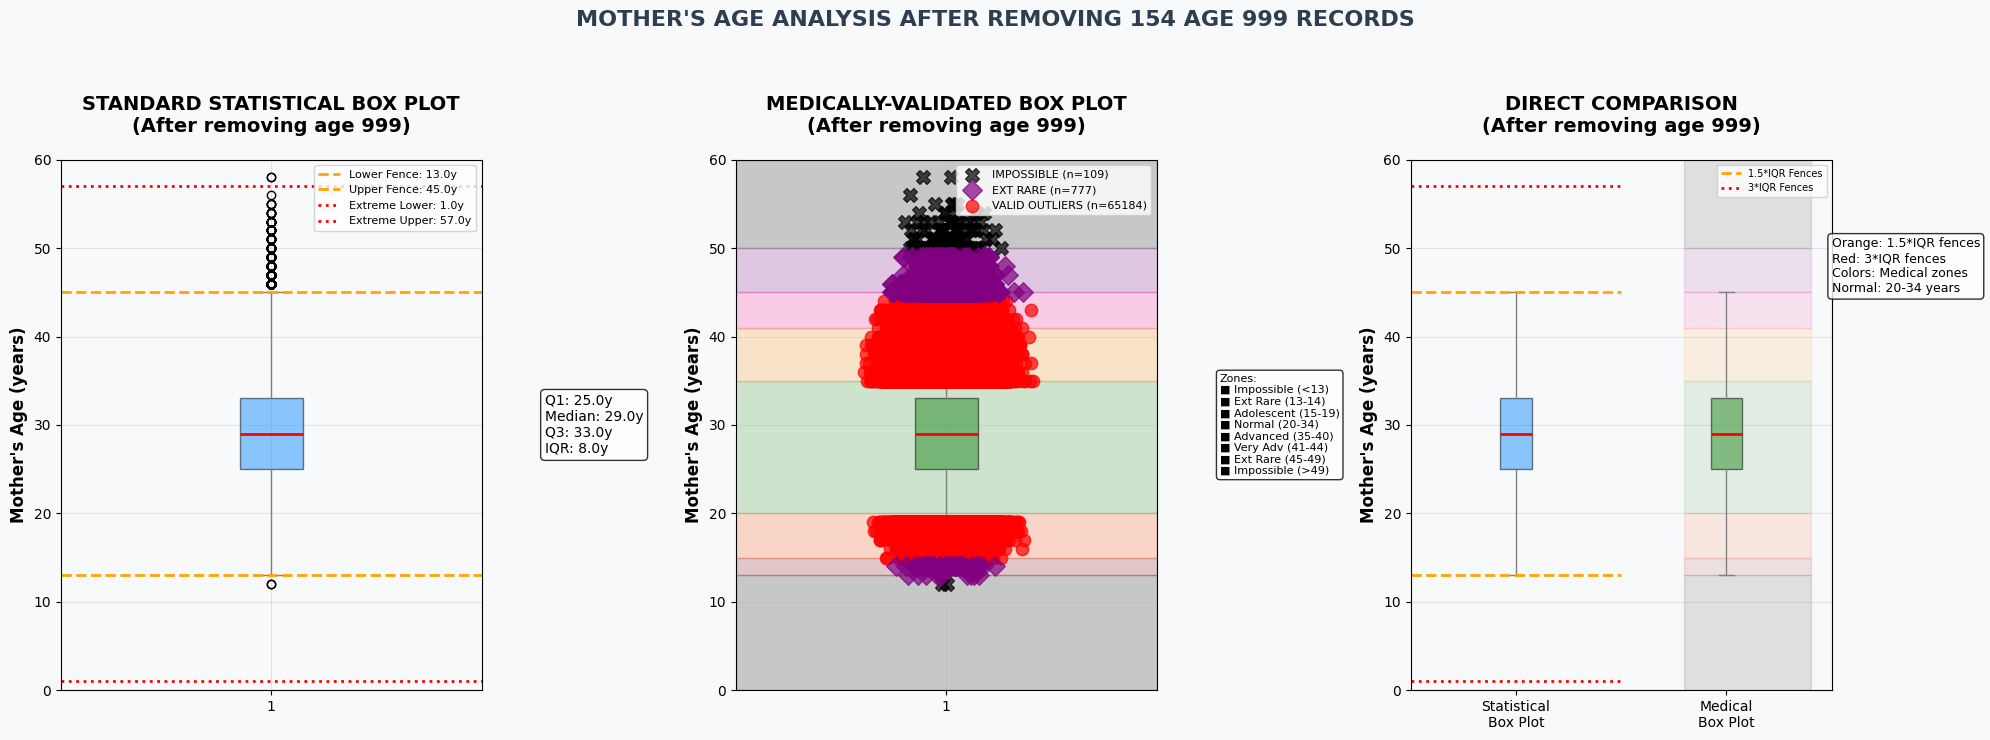

✅ Saved: mother_age_analysis_after_removal.png

────────────────────────────────────────────────────────────────────────────────
📊 STEP 6: GENERATING UPDATED SUMMARY TABLE
────────────────────────────────────────────────────────────────────────────────

                                     Category  Count Percentage
               Total Records (after removal) 301558       100%
                  Statistical Outliers (IQR)    528       0.2%
        Extreme Statistical Outliers (3*IQR)      2       0.0%
            IMPOSSIBLE - Remove (<13 or >49)    109       0.0%
     EXTREMELY RARE - Verify (13-14 & 45-49)    777       0.3%
VALID MEDICAL OUTLIERS - Keep (15-19, 35-44)  65184      21.6%
                       NORMAL - Keep (20-34) 235488      78.1%
                True Outliers (Both methods)    109       0.0%
          False Positives (Statistical only)    419       0.1%
                Medical Only (Clinical only)  65542      21.7%

───────────────────────────────────────────────────

In [5]:
# ============================================
# REMOVE AGE 999 RECORDS AND REGENERATE ALL RESULTS
# ============================================

print("="*80)
print("🔍 REMOVING AGE 999 RECORDS AND REGENERATING ANALYSIS")
print("="*80)

# ============================================
# STEP 1: REMOVE AGE 999 RECORDS
# ============================================
print(f"\n{'─'*80}")
print("📌 STEP 1: REMOVING AGE 999 RECORDS")
print('─'*80)

# Count age 999 records
age_999_count = len(mother_age_data[mother_age_data == 999])
print(f"   • Age 999 records found: {age_999_count}")

if age_999_count > 0:
    # Remove age 999 records
    clean_mask = mother_age_data != 999
    mother_age_clean = mother_age_data[clean_mask]
    
    # Also clean the original dataframe if it exists
    if 'df' in locals() and AGE_COLUMN in df.columns:
        df_clean = df[df[AGE_COLUMN] != 999].copy()
        print(f"   • Removed {age_999_count} records with age 999")
        print(f"   • New dataset size: {len(mother_age_clean):,} records")
    else:
        mother_age_clean = mother_age_data[mother_age_data != 999]
        print(f"   • Removed {age_999_count} records with age 999")
        print(f"   • New dataset size: {len(mother_age_clean):,} records")
else:
    mother_age_clean = mother_age_data
    print(f"   • No age 999 records found")
    print(f"   • Dataset size: {len(mother_age_clean):,} records")

# ============================================
# STEP 2: RECALCULATE STATISTICAL PARAMETERS
# ============================================
print(f"\n{'─'*80}")
print("📊 STEP 2: RECALCULATING STATISTICAL PARAMETERS")
print('─'*80)

# Statistical outliers (IQR method)
Q1_age = mother_age_clean.quantile(0.25)
Q3_age = mother_age_clean.quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_fence = Q1_age - 1.5 * IQR_age
upper_fence = Q3_age + 1.5 * IQR_age
lower_fence_extreme = Q1_age - 3 * IQR_age
upper_fence_extreme = Q3_age + 3 * IQR_age

stat_outliers = mother_age_clean[(mother_age_clean < lower_fence) | (mother_age_clean > upper_fence)]
stat_outliers_indices = stat_outliers.index
extreme_stat_outliers = mother_age_clean[(mother_age_clean < lower_fence_extreme) | (mother_age_clean > upper_fence_extreme)]

print(f"\n📈 UPDATED STATISTICAL SUMMARY:")
print(f"   • Mean: {mother_age_clean.mean():.1f} years")
print(f"   • Median: {mother_age_clean.median():.1f} years")
print(f"   • Q1: {Q1_age:.1f} years")
print(f"   • Q3: {Q3_age:.1f} years")
print(f"   • IQR: {IQR_age:.1f} years")
print(f"   • Lower fence (1.5*IQR): {lower_fence:.1f} years")
print(f"   • Upper fence (1.5*IQR): {upper_fence:.1f} years")
print(f"   • Total statistical outliers: {len(stat_outliers):,} ({(len(stat_outliers)/len(mother_age_clean)*100):.1f}%)")

# ============================================
# STEP 3: RECLASSIFY MEDICAL CATEGORIES
# ============================================
print(f"\n{'─'*80}")
print("🏥 STEP 3: RECLASSIFYING MEDICAL CATEGORIES")
print('─'*80)

# Medical classification
impossible_low = mother_age_clean[mother_age_clean < 13]
impossible_high = mother_age_clean[mother_age_clean > 49]
impossible = pd.concat([impossible_low, impossible_high])

rare_low = mother_age_clean[(mother_age_clean >= 13) & (mother_age_clean <= 14)]
rare_high = mother_age_clean[(mother_age_clean >= 45) & (mother_age_clean <= 49)]
rare = pd.concat([rare_low, rare_high])

adolescent = mother_age_clean[(mother_age_clean >= 15) & (mother_age_clean <= 19)]
normal = mother_age_clean[(mother_age_clean >= 20) & (mother_age_clean <= 34)]
advanced = mother_age_clean[(mother_age_clean >= 35) & (mother_age_clean <= 40)]
very_advanced = mother_age_clean[(mother_age_clean >= 41) & (mother_age_clean <= 44)]

valid_outliers = pd.concat([adolescent, advanced, very_advanced])
medical_outliers_all = pd.concat([impossible, rare, valid_outliers])

print(f"""
📋 UPDATED MEDICAL CLASSIFICATION:

    IMPOSSIBLE VALUES (MUST REMOVE):
      • Count: {len(impossible):,}
      • Range: {impossible.min():.0f} - {impossible.max():.0f} years
      • Below 13: {len(impossible_low)} records
      • Above 49: {len(impossible_high)} records

    EXTREMELY RARE (NEEDS VERIFICATION):
      • Count: {len(rare):,}
      • Range: {rare.min():.0f} - {rare.max():.0f} years
      • Ages 13-14: {len(rare_low)} records
      • Ages 45-49: {len(rare_high)} records

    VALID MEDICAL OUTLIERS (KEEP):
      • Count: {len(valid_outliers):,}
      • Adolescent (15-19): {len(adolescent):,}
      • Advanced (35-40): {len(advanced):,}
      • Very Advanced (41-44): {len(very_advanced):,}

    NORMAL RANGE (KEEP):
      • Count: {len(normal):,}
      • Ages 20-34 years
""")

# ============================================
# STEP 4: RECALCULATE OVERLAP ANALYSIS
# ============================================
print(f"\n{'─'*80}")
print("🔄 STEP 4: RECALCULATING OVERLAP ANALYSIS")
print('─'*80)

# Overlap analysis
false_positives = stat_outliers[(stat_outliers >= 15) & (stat_outliers <= 49)]
true_outliers = stat_outliers[(stat_outliers < 15) | (stat_outliers > 49)]
medical_only = medical_outliers_all[~medical_outliers_all.index.isin(stat_outliers_indices)]

print(f"""
📊 UPDATED OVERLAP RESULTS:

    TRUE OUTLIERS (Statistical + Medical):
      • Count: {len(true_outliers)}
      • Values: {sorted(true_outliers.unique()) if len(true_outliers) > 0 else 'None'}
      • Correctly identified by both methods

    FALSE POSITIVES (Statistical but Medically Normal):
      • Count: {len(false_positives)}
      • Values: {sorted(false_positives.unique()) if len(false_positives) > 0 else 'None'}
      • Statistical outliers but ages 15-49 are medically possible

    MEDICAL ONLY (Medically Abnormal but NOT Statistical):
      • Count: {len(medical_only)}
      • Values: {sorted(medical_only.unique()) if len(medical_only) > 0 else 'None'}
      • Medically significant but not statistical outliers
""")

# ============================================
# STEP 5: GENERATE COMPARATIVE BOX PLOTS
# ============================================
print(f"\n{'─'*80}")
print("📊 STEP 5: GENERATING UPDATED BOX PLOTS")
print('─'*80)

fig = plt.figure(figsize=(20, 7))
fig.patch.set_facecolor('#f8f9fa')

# 1. STANDARD STATISTICAL BOX PLOT
ax1 = plt.subplot(1, 3, 1)
ax1.set_facecolor('#f8f9fa')

bp1 = ax1.boxplot(mother_age_clean, patch_artist=True, showfliers=True)
bp1['boxes'][0].set_facecolor('#1E90FF')
bp1['boxes'][0].set_alpha(0.5)
bp1['whiskers'][0].set_color('gray')
bp1['whiskers'][1].set_color('gray')
bp1['caps'][0].set_color('gray')
bp1['caps'][1].set_color('gray')
bp1['medians'][0].set_color('red')
bp1['medians'][0].set_linewidth(2)

# Add statistical fence lines
ax1.axhline(y=lower_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Lower Fence: {lower_fence:.1f}y')
ax1.axhline(y=upper_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Upper Fence: {upper_fence:.1f}y')
ax1.axhline(y=lower_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Lower: {lower_fence_extreme:.1f}y')
ax1.axhline(y=upper_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Upper: {upper_fence_extreme:.1f}y')

ax1.set_ylabel('Mother\'s Age (years)', fontsize=12, fontweight='bold')
ax1.set_title('STANDARD STATISTICAL BOX PLOT\n(After removing age 999)', 
             fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 60)

# Add statistical summary text
stats_text = f"Q1: {Q1_age:.1f}y\nMedian: {mother_age_clean.median():.1f}y\nQ3: {Q3_age:.1f}y\nIQR: {IQR_age:.1f}y"
ax1.text(1.15, 0.5, stats_text, transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='center')

# 2. MEDICALLY-VALIDATED BOX PLOT
ax2 = plt.subplot(1, 3, 2)
ax2.set_facecolor('#f8f9fa')

bp2 = ax2.boxplot(mother_age_clean, patch_artist=True, showfliers=False)
bp2['boxes'][0].set_facecolor('#228B22')
bp2['boxes'][0].set_alpha(0.5)
bp2['whiskers'][0].set_color('gray')
bp2['whiskers'][1].set_color('gray')
bp2['caps'][0].set_color('gray')
bp2['caps'][1].set_color('gray')
bp2['medians'][0].set_color('red')
bp2['medians'][0].set_linewidth(2)

# Add medical possibility zone boundaries
age_boundaries = [0, 13, 15, 20, 35, 41, 45, 50, 60]
age_colors = ['black', '#8B0000', '#FF4500', '#228B22', '#FF8C00', '#FF1493', '#800080', 'black']

for i, boundary in enumerate(age_boundaries[:-1]):
    ax2.axhspan(boundary, age_boundaries[i+1], alpha=0.2, color=age_colors[i])

# Add colored scatter for different groups
if len(impossible) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(impossible))], 
               impossible['value'] if hasattr(impossible, 'value') else impossible, 
               color='black', alpha=0.7, marker='X', s=100,
               label=f'IMPOSSIBLE (n={len(impossible)})', zorder=5)

if len(rare) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(rare))], 
               rare['value'] if hasattr(rare, 'value') else rare, 
               color='purple', alpha=0.7, marker='D', s=100,
               label=f'EXT RARE (n={len(rare)})', zorder=5)

if len(valid_outliers) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(valid_outliers))], 
               valid_outliers['value'] if hasattr(valid_outliers, 'value') else valid_outliers, 
               color='red', alpha=0.7, s=80,
               label=f'VALID OUTLIERS (n={len(valid_outliers)})', zorder=4)

ax2.set_ylabel('Mother\'s Age (years)', fontsize=12, fontweight='bold')
ax2.set_title('MEDICALLY-VALIDATED BOX PLOT\n(After removing age 999)', 
             fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 60)

# Add medical zone legend
zone_text = "Zones:\n■ Impossible (<13)\n■ Ext Rare (13-14)\n■ Adolescent (15-19)\n■ Normal (20-34)\n■ Advanced (35-40)\n■ Very Adv (41-44)\n■ Ext Rare (45-49)\n■ Impossible (>49)"
ax2.text(1.15, 0.5, zone_text, transform=ax2.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='center')

# 3. COMBINED COMPARISON PLOT
ax3 = plt.subplot(1, 3, 3)
ax3.set_facecolor('#f8f9fa')

# Create side-by-side box plots
data_to_plot = [mother_age_clean, mother_age_clean]
positions = [1, 2]
bp3 = ax3.boxplot(data_to_plot, positions=positions, patch_artist=True, showfliers=False)
bp3['boxes'][0].set_facecolor('#1E90FF')
bp3['boxes'][0].set_alpha(0.5)
bp3['boxes'][1].set_facecolor('#228B22')
bp3['boxes'][1].set_alpha(0.5)
for i in range(4):
    bp3['whiskers'][i].set_color('gray')
    bp3['caps'][i].set_color('gray')
bp3['medians'][0].set_color('red')
bp3['medians'][1].set_color('red')
bp3['medians'][0].set_linewidth(2)
bp3['medians'][1].set_linewidth(2)

# Add statistical fences on first box
ax3.plot([0.5, 1.5], [lower_fence, lower_fence], 'orange', linestyle='--', linewidth=2, label='1.5*IQR Fences')
ax3.plot([0.5, 1.5], [upper_fence, upper_fence], 'orange', linestyle='--', linewidth=2)
ax3.plot([0.5, 1.5], [lower_fence_extreme, lower_fence_extreme], 'red', linestyle=':', linewidth=2, label='3*IQR Fences')
ax3.plot([0.5, 1.5], [upper_fence_extreme, upper_fence_extreme], 'red', linestyle=':', linewidth=2)

# Add medical zones on second box
for i, boundary in enumerate(age_boundaries[:-1]):
    ax3.axhspan(boundary, age_boundaries[i+1], alpha=0.1, color=age_colors[i], xmin=0.65, xmax=0.95)

ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Statistical\nBox Plot', 'Medical\nBox Plot'])
ax3.set_ylabel('Mother\'s Age (years)', fontsize=12, fontweight='bold')
ax3.set_title('DIRECT COMPARISON\n(After removing age 999)', 
             fontsize=14, fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, 60)
ax3.legend(loc='upper right', fontsize=7, frameon=True, facecolor='white')

# Add explanation
compare_text = "Orange: 1.5*IQR fences\nRed: 3*IQR fences\nColors: Medical zones\nNormal: 20-34 years"
ax3.text(2.5, 45, compare_text, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle(f'MOTHER\'S AGE ANALYSIS AFTER REMOVING {age_999_count} AGE 999 RECORDS', 
            fontsize=16, fontweight='bold', y=1.05, color='#2c3e50')
plt.tight_layout()
plt.savefig('mother_age_analysis_after_removal.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("✅ Saved: mother_age_analysis_after_removal.png")

# ============================================
# STEP 6: GENERATE UPDATED SUMMARY TABLE
# ============================================
print(f"\n{'─'*80}")
print("📊 STEP 6: GENERATING UPDATED SUMMARY TABLE")
print('─'*80)

summary_data = {
    'Category': [
        'Total Records (after removal)',
        'Statistical Outliers (IQR)',
        'Extreme Statistical Outliers (3*IQR)',
        'IMPOSSIBLE - Remove (<13 or >49)',
        'EXTREMELY RARE - Verify (13-14 & 45-49)',
        'VALID MEDICAL OUTLIERS - Keep (15-19, 35-44)',
        'NORMAL - Keep (20-34)',
        'True Outliers (Both methods)',
        'False Positives (Statistical only)',
        'Medical Only (Clinical only)'
    ],
    'Count': [
        len(mother_age_clean),
        len(stat_outliers),
        len(extreme_stat_outliers),
        len(impossible),
        len(rare),
        len(valid_outliers),
        len(normal),
        len(true_outliers),
        len(false_positives),
        len(medical_only)
    ],
    'Percentage': [
        "100%",
        f"{(len(stat_outliers)/len(mother_age_clean)*100):.1f}%",
        f"{(len(extreme_stat_outliers)/len(mother_age_clean)*100):.1f}%",
        f"{(len(impossible)/len(mother_age_clean)*100):.1f}%",
        f"{(len(rare)/len(mother_age_clean)*100):.1f}%",
        f"{(len(valid_outliers)/len(mother_age_clean)*100):.1f}%",
        f"{(len(normal)/len(mother_age_clean)*100):.1f}%",
        f"{(len(true_outliers)/len(mother_age_clean)*100):.1f}%",
        f"{(len(false_positives)/len(mother_age_clean)*100):.1f}%",
        f"{(len(medical_only)/len(mother_age_clean)*100):.1f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

# ============================================
# STEP 7: EXPORT UPDATED RESULTS TO EXCEL
# ============================================
print(f"\n{'─'*80}")
print("📁 STEP 7: EXPORTING UPDATED RESULTS TO EXCEL")
print('─'*80)

excel_filename = 'mother_age_analysis_after_removal.xlsx'

# Create a DataFrame with all classified records
all_records_df = pd.DataFrame({
    'Age': mother_age_clean.values,
    'Statistical_Outlier': mother_age_clean.index.isin(stat_outliers_indices),
    'Extreme_Statistical': mother_age_clean.index.isin(extreme_stat_outliers.index),
    'Medical_Category': 'Unknown'
})

# Assign medical categories
all_records_df.loc[mother_age_clean.index.isin(impossible.index), 'Medical_Category'] = 'IMPOSSIBLE (Remove)'
all_records_df.loc[mother_age_clean.index.isin(rare.index), 'Medical_Category'] = 'EXTREMELY RARE (Verify)'
all_records_df.loc[mother_age_clean.index.isin(adolescent.index), 'Medical_Category'] = 'Adolescent (Keep)'
all_records_df.loc[mother_age_clean.index.isin(normal.index), 'Medical_Category'] = 'Normal (Keep)'
all_records_df.loc[mother_age_clean.index.isin(advanced.index), 'Medical_Category'] = 'Advanced (Keep)'
all_records_df.loc[mother_age_clean.index.isin(very_advanced.index), 'Medical_Category'] = 'Very Advanced (Keep)'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Summary sheet
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    # Statistical summary
    stats_df = pd.DataFrame({
        'Parameter': ['Mean', 'Median', 'Q1', 'Q3', 'IQR', 'Lower Fence', 'Upper Fence', 
                      'Extreme Lower', 'Extreme Upper'],
        'Value': [mother_age_clean.mean(), mother_age_clean.median(), Q1_age, Q3_age, IQR_age,
                  lower_fence, upper_fence, lower_fence_extreme, upper_fence_extreme]
    })
    stats_df.to_excel(writer, sheet_name='Statistical_Summary', index=False)
    
    # All classified records
    all_records_df.to_excel(writer, sheet_name='All_Classified', index=False)
    
    # Impossible values
    if len(impossible) > 0:
        impossible_df = pd.DataFrame({'Age': impossible.values})
        impossible_df.to_excel(writer, sheet_name='IMPOSSIBLE_Remove', index=False)
    
    # Rare values
    if len(rare) > 0:
        rare_df = pd.DataFrame({'Age': rare.values})
        rare_df.to_excel(writer, sheet_name='Rare_Verify', index=False)
    
    # Valid outliers
    if len(valid_outliers) > 0:
        valid_df = pd.DataFrame({'Age': valid_outliers.values})
        valid_df.to_excel(writer, sheet_name='Valid_Outliers_Keep', index=False)

print(f"✅ Excel report saved: {excel_filename}")

# ============================================
# STEP 8: FINAL SUMMARY
# ============================================
print(f"\n{'='*80}")
print("✅ FINAL SUMMARY AFTER REMOVING AGE 999 RECORDS")
print('='*80)
print(f"""
📊 COMPARISON: BEFORE vs AFTER REMOVAL

    BEFORE REMOVAL:
    • Total records: {len(mother_age_data):,}
    • Age 999 records: {age_999_count:,}

    AFTER REMOVAL:
    • Total records: {len(mother_age_clean):,}
    • Statistical outliers: {len(stat_outliers):,} ({(len(stat_outliers)/len(mother_age_clean)*100):.1f}%)
    • Medical outliers: {len(medical_outliers_all):,} ({(len(medical_outliers_all)/len(mother_age_clean)*100):.1f}%)
    • Impossible values to remove: {len(impossible):,}
    • Rare values to verify: {len(rare):,}
    • Valid outliers to keep: {len(valid_outliers):,}
    • Normal values: {len(normal):,}

📁 FILES GENERATED:
    • PNG: mother_age_analysis_after_removal.png
    • Excel: {excel_filename}

📋 RECOMMENDATIONS:
    • REMOVE {len(impossible)} records (ages <13 or >49)
    • VERIFY {len(rare)} records (ages 13-14 & 45-49) with medical records
    • KEEP all {len(valid_outliers) + len(normal)} records for analysis
    • Final analysis dataset: {len(mother_age_clean) - len(impossible)} records
""")
print('='*80)